In [1]:
import torch.nn as nn
import torch
from torch.utils.data import DataLoader
from model_DataLoader import EEGDataset
from preprocessing_DataReader import PreprocessingDataReader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

In [3]:
class EEG_LSTM(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 100, num_layers: int = 1, output_size: int = 1):
        super(EEG_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


In [19]:
path = '../data/physionet.org/files/eegmmidb/1.0.0'
reader = PreprocessingDataReader(path=path)
reader.load(patient=[1,2], experiment=[3])
reader.normalize(norm_type="min-max")
data_edf = reader.get()

dataset = EEGDataset(data_edf)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

Reading EDF rom patient: 002: 100%|██████████| 29/29 [00:00<00:00, 174.22it/s]


In [ ]:
input_size = dataset.sequences.shape[2]
hidden_size = 64
num_layers = 2
num_classes = len(set(dataset.sequence_labels))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = EEG_LSTM(input_size, hidden_size, num_layers, num_classes).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Using device: cuda


In [ ]:
num_epochs = 400
losses = []

# Training loop with loss tracking
for epoch in range(num_epochs):
    epoch_loss = 0
    for X, y in dataloader:
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# Plot training loss over epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()

Epoch 1, Loss: 1.0449
Epoch 2, Loss: 1.0340
Epoch 3, Loss: 1.0275
Epoch 4, Loss: 1.0228


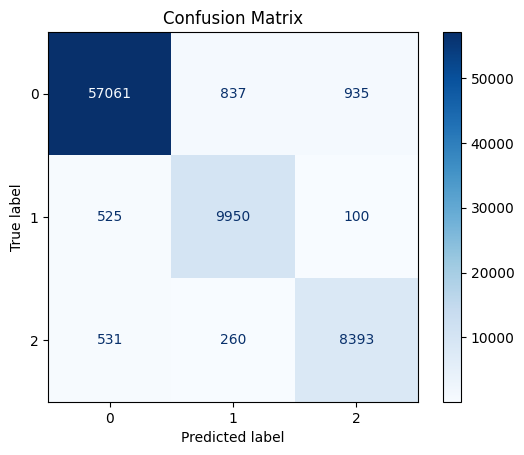

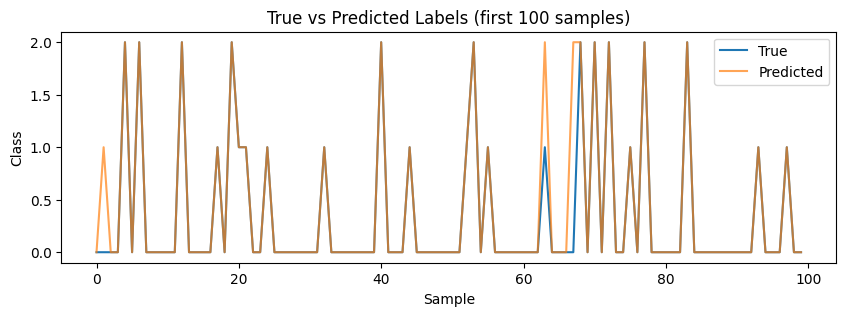

In [28]:
# Put model in evaluation mode
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in dataloader:
        X = X.to(device) 
        y = y.to(device)  
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Plot a few predictions vs. true labels
plt.figure(figsize=(10, 3))
plt.plot(all_labels[:100], label='True')
plt.plot(all_preds[:100], label='Predicted', alpha=0.7)
plt.legend()
plt.title("True vs Predicted Labels (first 100 samples)")
plt.xlabel("Sample")
plt.ylabel("Class")
plt.show()